# EMNIST Digits CNN Training

Training a Convolutional Neural Network on the EMNIST Digits dataset for 0-9 recognition.

Architecture inspired by [aviban15/cnn-mnist](https://github.com/aviban15/cnn-mnist), adapted to Keras.

Output: ONNX model for cross-platform inference.

## 1. Imports & Setup

In [9]:
import os
import gzip
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

# Check for GPU acceleration (M4 Mac via tensorflow-metal)
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs available: {gpus}")

TensorFlow version: 2.16.2
Keras version: 3.10.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Load EMNIST Digits Data

The EMNIST Digits dataset uses the standard IDX format (same as original MNIST), with gzip compression.

**Key EMNIST details:**
- Labels 1-10 map to digits 0-9 (we subtract 1 to get 0-9)
- Images are stored with a 90° rotation + horizontal flip vs. standard MNIST orientation
- We correct this with a transpose (`.T`)

In [10]:
DATA_DIR = os.path.join(os.getcwd(), 'training')

def read_idx_gz(filepath):
    """Read a gzipped IDX file and return the numpy array."""
    with gzip.open(filepath, 'rb') as f:
        magic = int.from_bytes(f.read(4), 'big')
        ndim = magic % 256
        dims = [int.from_bytes(f.read(4), 'big') for _ in range(ndim)]
        data = np.frombuffer(f.read(), dtype=np.uint8).reshape(dims)
    return data

# Load training images and labels
train_images_raw = read_idx_gz(os.path.join(DATA_DIR, 'emnist-digits-train-images-idx3-ubyte.gz'))
train_labels_raw = read_idx_gz(os.path.join(DATA_DIR, 'emnist-digits-train-labels-idx1-ubyte.gz'))

# Load test images and labels (used as validation)
test_images_raw = read_idx_gz(os.path.join(DATA_DIR, 'emnist-digits-test-images-idx3-ubyte.gz'))
test_labels_raw = read_idx_gz(os.path.join(DATA_DIR, 'emnist-digits-test-labels-idx1-ubyte.gz'))

print(f"Train images shape: {train_images_raw.shape}")
print(f"Train labels shape: {train_labels_raw.shape}")
print(f"Test (val) images shape:  {test_images_raw.shape}")
print(f"Test (val) labels shape:  {test_labels_raw.shape}")
print(f"\nLabel range: {train_labels_raw.min()} to {train_labels_raw.max()}")
print(f"Unique labels in train: {np.unique(train_labels_raw)}")

Train images shape: (240000, 28, 28)
Train labels shape: (240000,)
Test (val) images shape:  (40000, 28, 28)
Test (val) labels shape:  (40000,)

Label range: 0 to 9
Unique labels in train: [0 1 2 3 4 5 6 7 8 9]


## 3. EMNIST Orientation Correction

EMNIST images are stored rotated 90° clockwise and mirrored. Fix by transposing each 28x28 image.
Labels 1-10 are remapped to 0-9.

In [23]:
def correct_emnist_orientation(images):
    """Transpose each 28x28 image to correct EMNIST rotation."""
    corrected = np.zeros_like(images)
    for i in range(images.shape[0]):
        corrected[i] = images[i].T
    return corrected

# Correct orientation
x_train = correct_emnist_orientation(train_images_raw)
x_val = correct_emnist_orientation(test_images_raw)

# Filter out any out-of-range labels (safety check)
train_mask = (y_train >= 0) & (y_train <= 9)
val_mask = (y_val >= 0) & (y_val <= 9)
x_train = x_train[train_mask]
y_train = y_train[train_mask]
x_val = x_val[val_mask]
y_val = y_val[val_mask]

print(f"Training data:   {x_train.shape}, labels {y_train.min()}-{y_train.max()}")
print(f"Validation data: {x_val.shape},   labels {y_val.min()}-{y_val.max()}")
print(f"Label distribution (train): {np.bincount(y_train)}")

Training data:   (240000, 28, 28), labels 0-9
Validation data: (40000, 28, 28),   labels 0-9
Label distribution (train): [24000 24000 24000 24000 24000 24000 24000 24000 24000 24000]


## 4. Visualize Samples

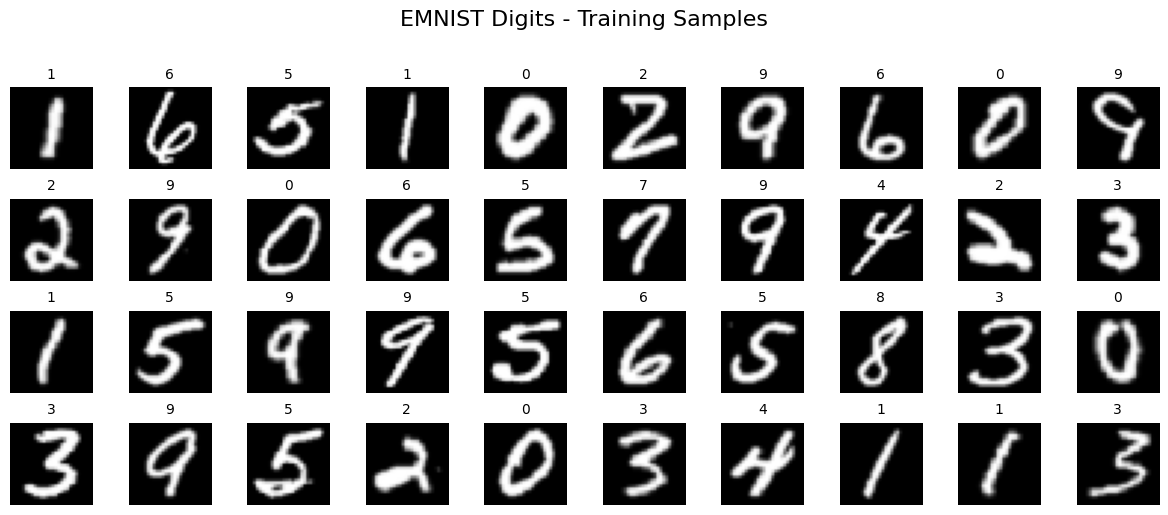

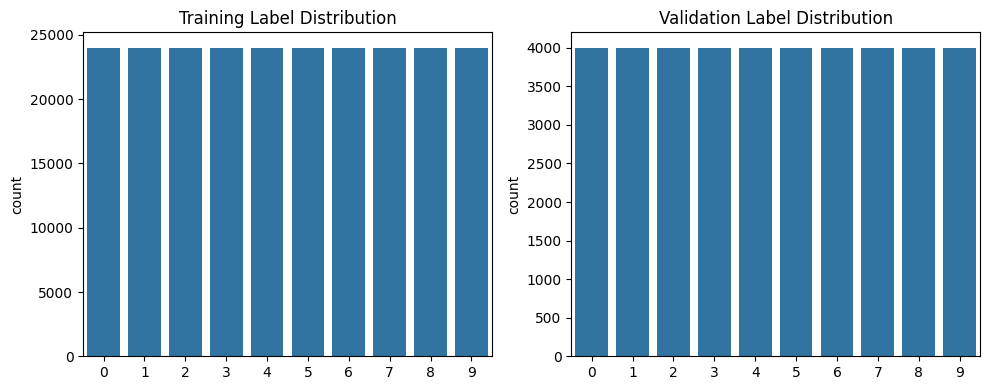

Total train: 240000, total val: 40000


In [24]:
def plot_digit_grid(images, labels, num_rows=4, num_cols=10, title='EMNIST Digits'):
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 5))
    fig.suptitle(title, fontsize=16, y=1.02)
    for i in range(num_rows * num_cols):
        ax = axes[i // num_cols][i % num_cols]
        idx = np.random.randint(0, len(images))
        ax.imshow(images[idx], cmap='gray')
        ax.set_title(f'{labels[idx]}', fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

plot_digit_grid(x_train, y_train, title='EMNIST Digits - Training Samples')

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.countplot(x=y_train)
plt.title('Training Label Distribution')
plt.subplot(1, 2, 2)
sns.countplot(x=y_val)
plt.title('Validation Label Distribution')
plt.tight_layout()
plt.show()

print(f"Total train: {len(y_train)}, total val: {len(y_val)}")

## 5. Data Preprocessing

- Normalize pixel values to [0, 1]
- Add channel dimension for Conv2D input
- One-hot encode labels
- The dataset already has a train/test split; test set is used as validation

In [25]:
# Normalize to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_val = x_val.astype('float32') / 255.0

# Add channel dimension -> (N, 28, 28, 1) for Conv2D input
x_train = np.expand_dims(x_train, axis=-1)
x_val = np.expand_dims(x_val, axis=-1)

# One-hot encode labels
num_classes = 10
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_val_cat = keras.utils.to_categorical(y_val, num_classes)

print(f"Training set:   {x_train.shape}, {y_train_cat.shape}")
print(f"Validation set: {x_val.shape},   {y_val_cat.shape}")

Training set:   (240000, 28, 28, 1), (240000, 10)
Validation set: (40000, 28, 28, 1),   (40000, 10)


## 6. CNN Model Architecture

Adapted from the reference PyTorch architecture ([aviban15/cnn-mnist](https://github.com/aviban15/cnn-mnist)):

- **Block 1**: Conv(16) -> BN -> ReLU -> Conv(16) -> BN -> ReLU -> MaxPool -> Dropout
- **Block 2**: Conv(32) -> BN -> ReLU -> Conv(32) -> BN -> ReLU -> MaxPool -> Dropout
- **Block 3**: Conv(16, 1x1 bottleneck) -> BN -> ReLU -> Conv(16) -> BN -> ReLU
- **Global Average Pooling** -> Dense(10, Softmax)

Total parameters: ~20K

In [26]:
def build_emnist_cnn(input_shape=(28, 28, 1), num_classes=10):
    inputs = layers.Input(shape=input_shape, name='input')

    # Block 1: 16 -> 16 filters
    x = layers.Conv2D(16, (3, 3), padding='same', name='conv1_1')(inputs)
    x = layers.BatchNormalization(name='bn1_1')(x)
    x = layers.ReLU(name='relu1_1')(x)
    x = layers.Conv2D(16, (3, 3), padding='same', name='conv1_2')(x)
    x = layers.BatchNormalization(name='bn1_2')(x)
    x = layers.ReLU(name='relu1_2')(x)
    x = layers.MaxPooling2D((2, 2), name='pool1')(x)
    x = layers.Dropout(0.1, name='drop1')(x)

    # Block 2: 32 -> 32 filters
    x = layers.Conv2D(32, (3, 3), padding='same', name='conv2_1')(x)
    x = layers.BatchNormalization(name='bn2_1')(x)
    x = layers.ReLU(name='relu2_1')(x)
    x = layers.Conv2D(32, (3, 3), padding='same', name='conv2_2')(x)
    x = layers.BatchNormalization(name='bn2_2')(x)
    x = layers.ReLU(name='relu2_2')(x)
    x = layers.MaxPooling2D((2, 2), name='pool2')(x)
    x = layers.Dropout(0.1, name='drop2')(x)

    # Block 3: bottleneck and final conv
    x = layers.Conv2D(16, (1, 1), padding='valid', name='conv3_bottleneck')(x)
    x = layers.BatchNormalization(name='bn3_1')(x)
    x = layers.ReLU(name='relu3_1')(x)
    x = layers.Conv2D(16, (3, 3), padding='same', name='conv3_2')(x)
    x = layers.BatchNormalization(name='bn3_2')(x)
    x = layers.ReLU(name='relu3_2')(x)

    # Global Average Pooling
    x = layers.GlobalAveragePooling2D(name='gap')(x)

    # Output layer with softmax
    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name='emnist_cnn')
    return model

model = build_emnist_cnn()
model.summary()
print(f"\nTotal parameters: {model.count_params():,}")

Model: "emnist_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_1 (Conv2D)                │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_1 (BatchNormalization)      │ (None, 28, 28, 16)     │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1_1 (ReLU)                  │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 28, 28, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_2 (BatchNormalization)      │ (None, 28, 28, 16)     │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1_2 (ReLU)                  │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_1 (BatchNormalization)      │ (None, 14, 14, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2_1 (ReLU)                  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_2 (BatchNormalization)      │ (None, 14, 14, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2_2 (ReLU)                  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_bottleneck (Conv2D)       │ (None, 7, 7, 16)       │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_1 (BatchNormalization)      │ (None, 7, 7, 16)       │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3_1 (ReLU)                  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_2 (Conv2D)                │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_2 (BatchNormalization)      │ (None, 7, 7, 16)       │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3_2 (ReLU)                  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           17

 Total params: 19,898 (77.73 KB)

 Trainable params: 19,642 (76.73 KB)

 Non-trainable params: 256 (1.00 KB)


Total parameters: 19,898


## 7. Compile & Train

In [ ]:
optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, weight_decay=1e-4)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_list = [
    callbacks.EarlyStopping(patience=10, restore_best_weights=True, monitor='val_accuracy'),
    callbacks.ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-6, monitor='val_loss', verbose=1),
    callbacks.ModelCheckpoint('emnist_cnn.keras', save_best_only=True, monitor='val_accuracy'),
]

print("Starting training...")

Starting training...


In [28]:
history = model.fit(
    x_train, y_train_cat,
    batch_size=128,
    epochs=25,
    validation_data=(x_val, y_val_cat),
    callbacks=callbacks_list,
    verbose=1
)

print("\nTraining complete!")

Epoch 1/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 28ms/step - accuracy: 0.7904 - loss: 0.7537 - val_accuracy: 0.9749 - val_loss: 0.0882 - learning_rate: 0.0100
Epoch 2/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9869 - loss: 0.0522 - val_accuracy: 0.9905 - val_loss: 0.0333 - learning_rate: 0.0100
Epoch 3/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9893 - loss: 0.0398 - val_accuracy: 0.9914 - val_loss: 0.0309 - learning_rate: 0.0100
Epoch 4/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9914 - loss: 0.0314 - val_accuracy: 0.9930 - val_loss: 0.0233 - learning_rate: 0.0100
Epoch 5/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 29ms/step - accuracy: 0.9924 - loss: 0.0279 - val_accuracy: 0.9932 - val_loss: 0.0226 - learning_rate: 0.0100
Epoch 6/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 29ms/step - accuracy: 0.9926 - loss: 0.0263 - val_accuracy: 0.9934 - val_loss: 0.0227 - learning_rate: 0.0100
Epoch 7/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 31ms/step - accura

## 8. Training History

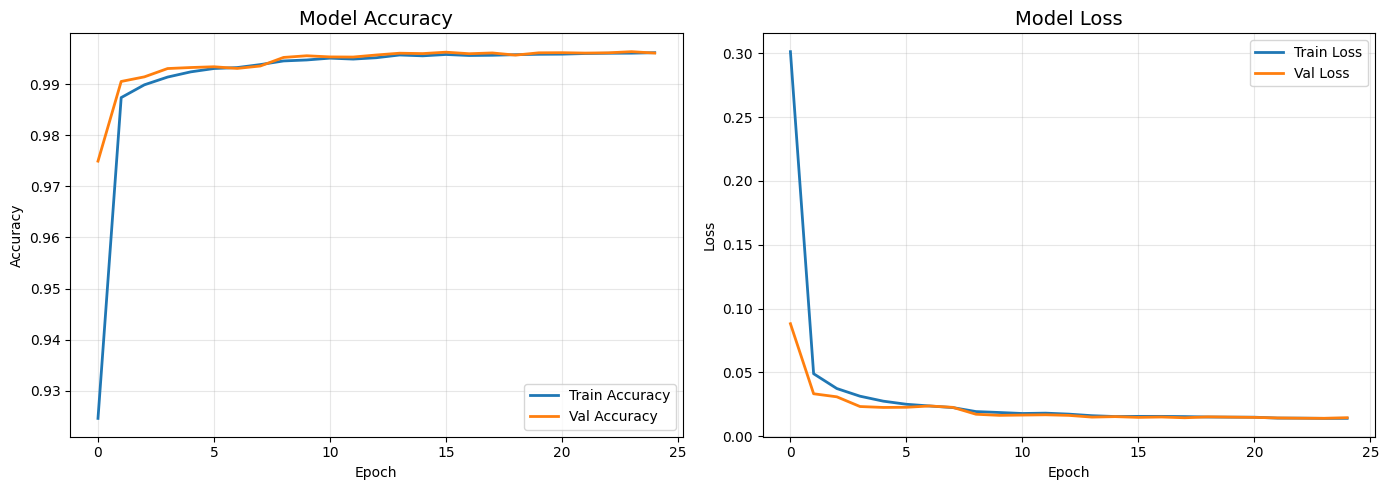

Best validation accuracy: 0.9963 at epoch 24


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_val_acc = max(history.history['val_accuracy'])
best_epoch = history.history['val_accuracy'].index(best_val_acc) + 1
print(f"Best validation accuracy: {best_val_acc:.4f} at epoch {best_epoch}")

## 9. Evaluate on Validation Set

Validation accuracy: 0.9963
Validation loss:     0.0141

Classification Report:
              precision    recall  f1-score   support

           0     0.9975    0.9965    0.9970      4000
           1     0.9990    0.9980    0.9985      4000
           2     0.9962    0.9940    0.9951      4000
           3     0.9958    0.9958    0.9958      4000
           4     0.9970    0.9955    0.9962      4000
           5     0.9972    0.9952    0.9962      4000
           6     0.9972    0.9970    0.9971      4000
           7     0.9953    0.9982    0.9968      4000
           8     0.9945    0.9962    0.9954      4000
           9     0.9935    0.9968    0.9951      4000

    accuracy                         0.9963     40000
   macro avg     0.9963    0.9963    0.9963     40000
weighted avg     0.9963    0.9963    0.9963     40000



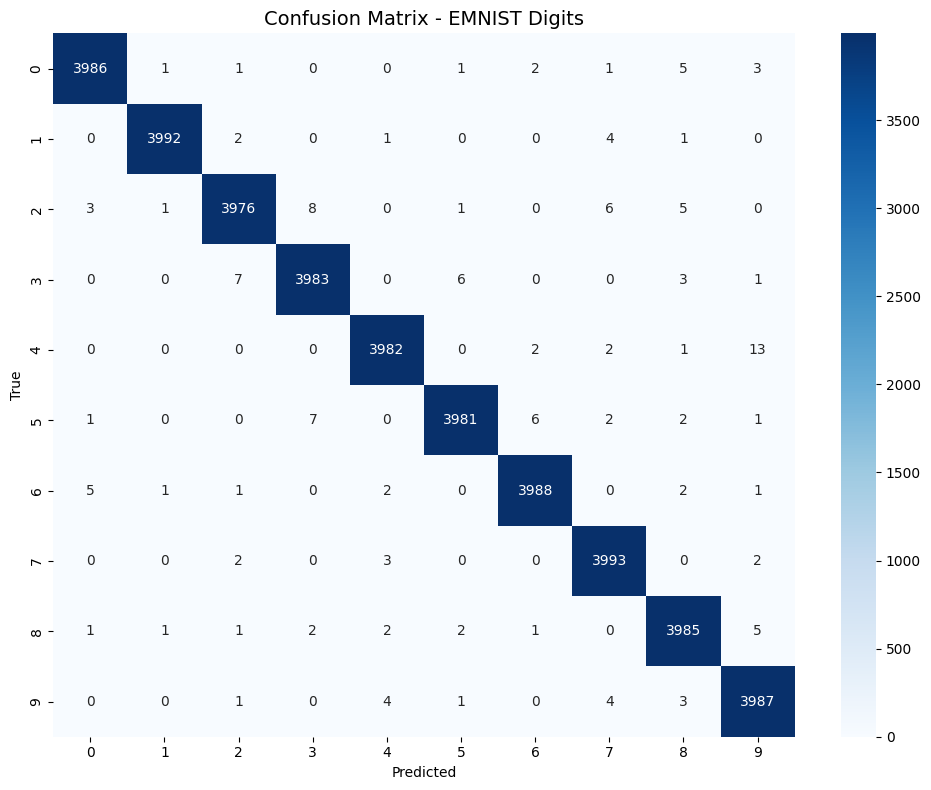


Total misclassified: 147 out of 40000


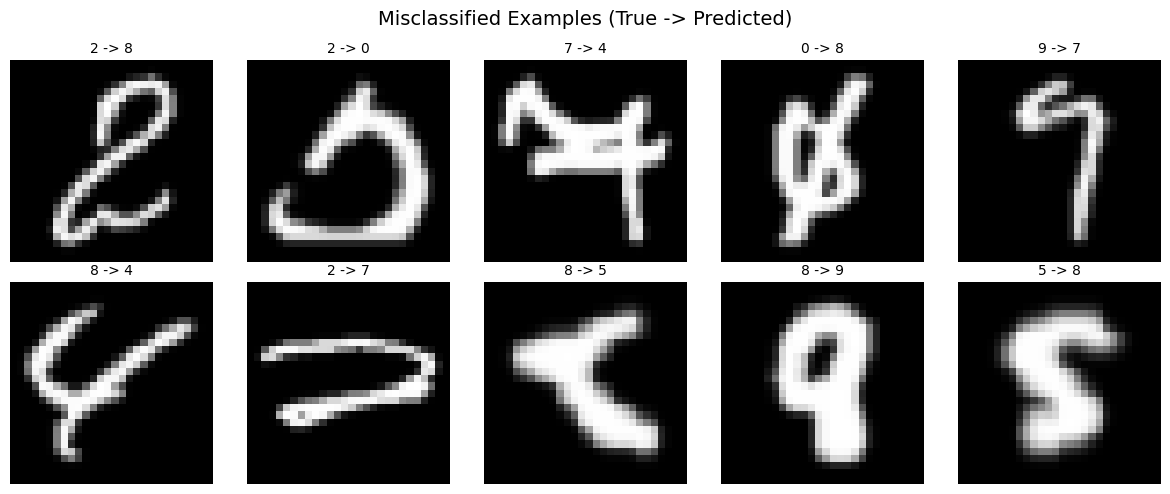

In [ ]:
best_model = keras.models.load_model('emnist_cnn.keras')

val_loss, val_acc = best_model.evaluate(x_val, y_val_cat, verbose=0)
print(f"Validation accuracy: {val_acc:.4f}")
print(f"Validation loss:     {val_loss:.4f}")

y_pred = best_model.predict(x_val, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_val_cat, axis=1)

print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes, digits=4))

cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix - EMNIST Digits', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

misclassified = np.where(y_pred_classes != y_true_classes)[0]
print(f"\nTotal misclassified: {len(misclassified)} out of {len(y_true_classes)}")

if len(misclassified) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle('Misclassified Examples (True -> Predicted)', fontsize=14)
    for i, ax in enumerate(axes.flat):
        if i < len(misclassified):
            idx = misclassified[i]
            ax.imshow(x_val[idx].reshape(28, 28), cmap='gray')
            ax.set_title(f'{y_true_classes[idx]} -> {y_pred_classes[idx]}', fontsize=10)
            ax.axis('off')
    plt.tight_layout()
    plt.show()

## 10. Export to ONNX

In [31]:
import tf2onnx

input_spec = [tf.TensorSpec([None, 28, 28, 1], tf.float32, name='input')]

onnx_model_path = 'emnist_cnn.onnx'
model_proto, _ = tf2onnx.convert.from_keras(
    best_model,
    input_signature=input_spec,
    opset=13,
    output_path=onnx_model_path
)

print(f"ONNX model saved to: {onnx_model_path}")
print(f"ONNX model input:  {model_proto.graph.input[0].name}")
print(f"ONNX model output: {model_proto.graph.output[0].name}")

2026-05-27 22:49:02.649054: I tensorflow/core/grappler/devices.cc:75] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
2026-05-27 22:49:02.649951: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-27 22:49:02.649962: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-05-27 22:49:02.770915: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-27 22:49:02.770937: I tensorflow/core/com

ONNX model saved to: emnist_cnn.onnx
ONNX model input:  input
ONNX model output: output


## 11. Verify ONNX Model

In [32]:
import onnx
import onnxruntime as ort

onnx_model = onnx.load(onnx_model_path)
onnx.checker.check_model(onnx_model)
print("✓ ONNX model structure is valid")

ort_session = ort.InferenceSession(onnx_model_path)
input_name = ort_session.get_inputs()[0].name
output_name = ort_session.get_outputs()[0].name

print(f"Input:  {input_name} -> {ort_session.get_inputs()[0].shape}")
print(f"Output: {output_name} -> {ort_session.get_outputs()[0].shape}")

for i in range(5):
    sample = x_val[i:i+1]
    keras_pred = best_model.predict(sample, verbose=0)[0]
    onnx_pred = ort_session.run([output_name], {input_name: sample})[0][0]

    print(f"\nSample {i}: True={y_true_classes[i]}")
    print(f"  Keras:  {np.argmax(keras_pred)} ({keras_pred[np.argmax(keras_pred)]:.4f})")
    print(f"  ONNX:   {np.argmax(onnx_pred)} ({onnx_pred[np.argmax(onnx_pred)]:.4f})")
    print(f"  Match: {np.allclose(keras_pred, onnx_pred, atol=1e-5)}")
    print(f"  Probs: {[f'{p:.4f}' for p in onnx_pred]}")

✓ ONNX model structure is valid
Input:  input -> ['unk__213', 28, 28, 1]
Output: output -> ['unk__214', 10]

Sample 0: True=0
  Keras:  0 (0.9996)
  ONNX:   0 (0.9996)
  Match: True
  Probs: ['0.9996', '0.0000', '0.0002', '0.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0.0002', '0.0000']

Sample 1: True=9
  Keras:  9 (1.0000)
  ONNX:   9 (1.0000)
  Match: True
  Probs: ['0.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0.0000', '1.0000']

Sample 2: True=7
  Keras:  7 (0.9997)
  ONNX:   7 (0.9997)
  Match: True
  Probs: ['0.0000', '0.0001', '0.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0.9997', '0.0000', '0.0002']

Sample 3: True=9
  Keras:  9 (1.0000)
  ONNX:   9 (1.0000)
  Match: True
  Probs: ['0.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0.0000', '1.0000']

Sample 4: True=2
  Keras:  2 (1.0000)
  ONNX:   2 (1.0000)
  Match: True
  Probs: ['0.0000', '0.0000', '1.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0

## 12. Summary

In [ ]:
print("=" * 60)
print("EMNIST CNN Training Complete!")
print("=" * 60)
print("\nGenerated files:")
print("  - emnist_cnn.keras   (Keras saved model)")
print("  - emnist_cnn.onnx    (ONNX model for inference)")
print("\nModel info:")
print("  - Input:  28x28x1 grayscale image")
print("  - Output: 10 probabilities (digits 0-9)")
print("  - Architecture: CNN with ~20K parameters (Keras)")

EMNIST CNN Training Complete!

Generated files:
  - best_emnist_model.keras   (Keras saved model)
  - emnist_cnn.onnx           (ONNX model for inference)

Model info:
  - Input:  28x28x1 grayscale image
  - Output: 10 probabilities (digits 0-9)
  - Architecture: CNN with ~20K parameters (Keras)
